Задание 2. Визуализация данных (Matplotlib)

Продолжаю работать с TMDB 5000 Movie Dataset из прошлого задания.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 2.2.2
NumPy: 2.0.2


In [23]:
url = "https://raw.githubusercontent.com/harshitcodes/tmdb_movie_data_analysis/master/tmdb-5000-movie-dataset/tmdb_5000_movies.csv"
df = pd.read_csv(url)
print("Dataset size:", df.shape)
df[['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']].describe()

Dataset size: (4803, 20)


,budget,revenue,runtime,popularity,vote_average,vote_count
count,4.803000e+03,4.803000e+03,4801.000000,4803.000000,4803.000000,4803.000000
mean,2.904504e+07,8.226064e+07,106.875859,21.492301,6.092172,690.217989
std,4.072239e+07,1.628571e+08,22.611935,31.816650,1.194612,1234.585891
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,7.900000e+05,0.000000e+00,94.000000,4.668070,5.600000,54.000000
50%,1.500000e+07,1.917000e+07,103.000000,12.921594,6.200000,235.000000
75%,4.000000e+07,9.291719e+07,118.000000,28.313505,6.800000,737.000000
max,3.800000e+08,2.787965e+09,338.000000,875.581305,10.000000,13752.000000


Для линейного графика колонку popularity и строю линию для первых 100 фильмов.

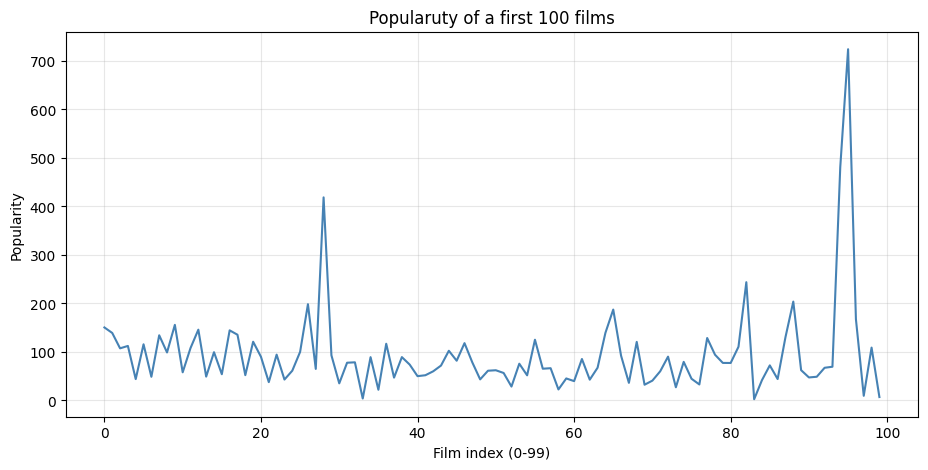

In [24]:
plt.figure(figsize=(11, 5))
plt.plot(range(100), df['popularity'].head(100), color='steelblue', linewidth=1.5)

plt.title('Popularuty of a first 100 films')
plt.xlabel('Film index (0-99)')
plt.ylabel('Popularity')
plt.grid(alpha=0.3)
plt.show()

Линейный график здесь показывает не временной ряд, а порядок строк в исходном файле. Видны редкие пики (отдельные суперпопулярные фильмы) Это знак того, что popularity распределена неравномерно и имеет длинный правый хвост.

Дл гистограммы распределения числовой признак длительность фильма (runtime). Нули отфильтровываю в этот раз.

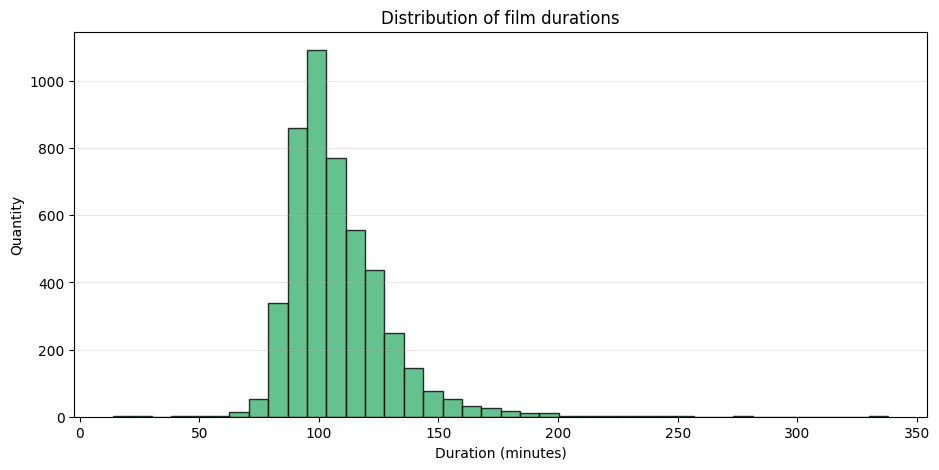

In [25]:
runtime = df[df['runtime'] > 0]['runtime']

plt.figure(figsize=(11, 5))
plt.hist(runtime, bins=40, color='mediumseagreen', edgecolor='black', alpha=0.8)

plt.title('Distribution of film durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Quantity')
plt.grid(axis='y', alpha=0.3)
plt.show()

При bins=40 (столбцы) чётко виден узкий пик в районе 90–120 минут (это стандартный полный метр). Распределение близко к нормальному, но с правым хвостом из редких очень длинных фильмов. Слишком маленький bins сгладил бы пик а слишком большой сделал бы график рваным.

Диаграмма рассеяния
Две колонки с ожидаемой связью (бюджет и сборы).

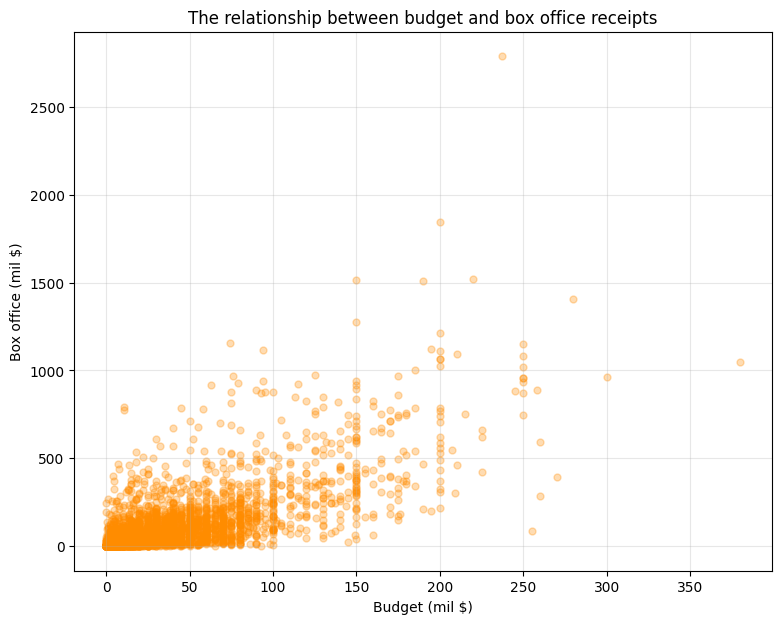

In [26]:
mask = (df['budget'] > 0) & (df['revenue'] > 0)

plt.figure(figsize=(9, 7))
plt.scatter(df[mask]['budget'] / 1e6, df[mask]['revenue'] / 1e6,
            alpha=0.3, color='darkorange', s=25)

plt.title('The relationship between budget and box office receipts')
plt.xlabel('Budget (mil $)')
plt.ylabel('Box office (mil $)')
plt.grid(alpha=0.3)
plt.show()

Можно заметить положительную связь. Чем больше бюджет, тем выше сборы. Основная масса точек сидит плотно в левом нижнем углу (малобюджетное кино со скромными сборами) а отдельные блокбастеры разлетаются вверх-вправо.

Генерация данных (numpy.random)
Современный рекомендованный способ это генератор default_rng(). Беру три распределения (нормальное, равномерное и экспоненциальное).

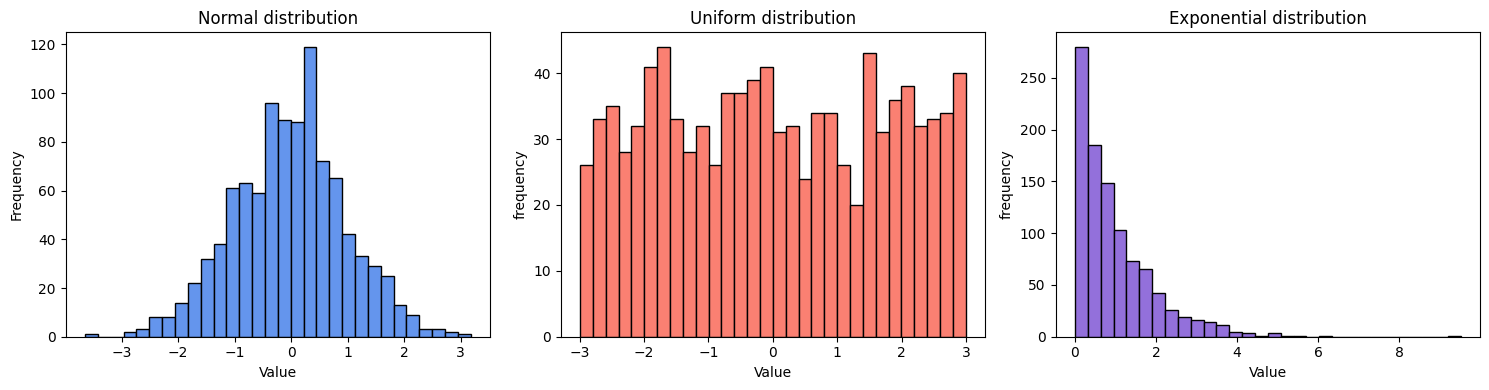

In [27]:
rng = np.random.default_rng(42)

normal_sample = rng.normal(loc=0, scale=1, size=1000)
uniform_sample = rng.uniform(low=-3, high=3, size=1000)
exponential_sample = rng.exponential(scale=1.0, size=1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(normal_sample, bins=30, color='cornflowerblue', edgecolor='black')
axes[0].set_title('Normal distribution')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Frequency')

axes[1].hist(uniform_sample, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Uniform distribution')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('frequency')

axes[2].hist(exponential_sample, bins=30, color='mediumpurple', edgecolor='black')
axes[2].set_title('Exponential distribution')
axes[2].set_xlabel('Value'); axes[2].set_ylabel('frequency')

plt.tight_layout()
plt.show()

Формы получились ровно такими, как ожидается из теории:
Нормальное представляет собой симметричный колокол с пиком около нуля, частоты спадают в обе стороны.
Равномерное: примерно одинаковая высота всех столбиков, плоское плато без выраженного пика.
Экспоненциальное: резкий пик у нуля и длинный хвост вправо. значений около нуля много, больших значений мало.

Форма runtime и budget из реального датасета напоминает скорее нормальное и экспоненциальное распределения соответственно то есть генерируемые распределения это упрощённые модели того, что встречается в реальных данных.

Boxplot с настроенными усами

По умолчанию усы boxplot строятся по правилу 1.5·IQR. По документации параметр whis можно задать списком перцентилей тогда усы пройдут строго по ним. Беру whis=[2, 98].

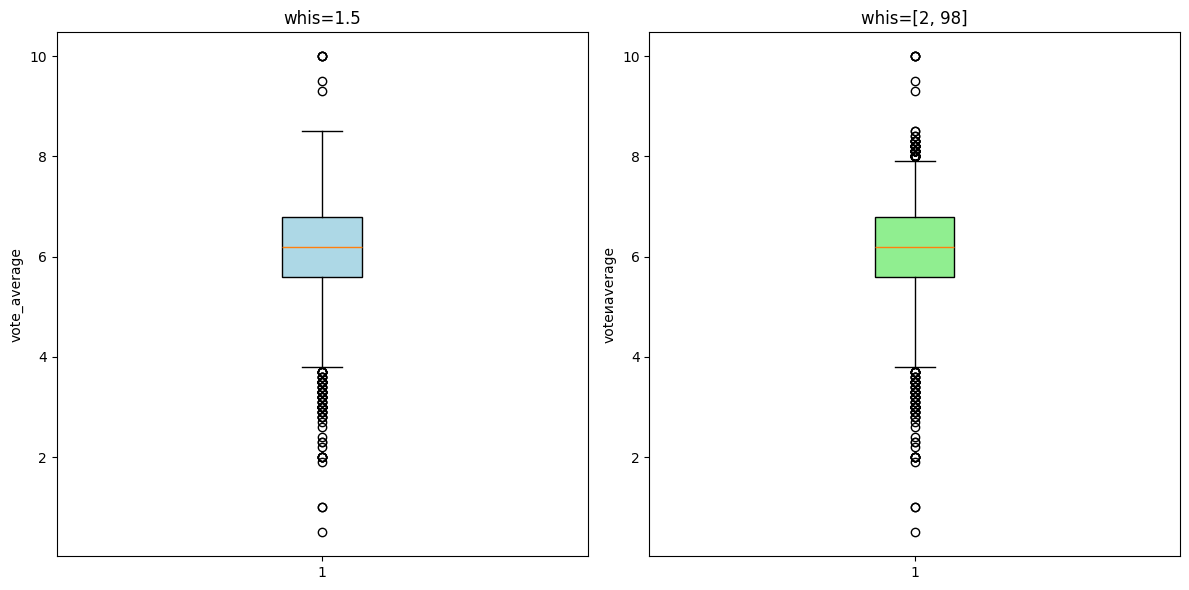

In [28]:
rating = df[df['vote_average'] > 0]['vote_average']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].boxplot(rating, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('whis=1.5')
axes[0].set_ylabel('vote_average')

axes[1].boxplot(rating, vert=True, whis=[2, 98], patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('whis=[2, 98]')
axes[1].set_ylabel('voteиaverage')

plt.tight_layout()
plt.show()

whis=[2, 98] задаёт усы по перцентилям (центральные 96% данных) вместо правила 1.5·IQR. Верхний ус опустился до 7.9 поэтому часть высоких рейтингов стала считаться выбросами. Так мы сами контролируем порог аномальности а не полагаемся на формулу по умолчанию.

Выводы
По датасету:
* popularity и budget имеют сильно скошенные распределения с длинным правым хвостом небольшое число блокбастеров кратно превосходит основную массу фильмов.
* runtime распределён почти нормально с пиком 90–120 минут тк  это стандарт полного метра.
* Scatter бюджет–сборы подтвердил положительную связь, но плотнее всего сидит малобюджетное кино а прибыльные исключения это редкие точки сверху.
* Нулевые значения в budget, revenue, runtim  это заглушки пропусков их обязательно надо фильтровать перед построением графиков иначе они искажают и гистограммы и boxplot.

По генерации распределений:

* numpy.random (через default_rng) позволяет получать выборки из разных распределений, а гистограмма сразу выдаёт их характерную форму.
* Наглядно видна разница: нормальное симметрично, равномерное плоское, экспоненциальное с пиком у нуля и хвостом. Эти же паттерны встречаются в реальных признаках датасета поэтому понимание формы распределений помогает выбирать правильные преобразования при подготовке данных.